# AegisSec-FedOps Week 3 XAI Deep Dive

## Global, directional, local and weakness explanations

This notebook explains the selected real-data model and
its operational weaknesses.

> The model classifies current CISA KEV membership. It
> does not predict future exploitation, replace SSVC,
> change affectedness or authorize remediation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.presentation_demo.xai_analysis import (
    load_xai_bundle,
)

xai = load_xai_bundle()
report = xai["report"]

print(
    "XAI stage gate:",
    report["quality_gate"]["stage_gate"],
)

print(
    "SSVC authority:",
    report["governance"][
        "authoritative_policy_engine"
    ],
)

print(
    "Model authority:",
    report["governance"][
        "model_authority"
    ],
)

print(
    "Production readiness:",
    report["governance"][
        "production_readiness"
    ],
)

XAI stage gate: PASS
SSVC authority: SSVC
Model authority: ADVISORY_ONLY
Production readiness: BLOCKED


## 1. Global directional explanation

The winning model is standardized Logistic Regression.

- Positive coefficients move the result toward current
  KEV membership.
- Negative coefficients move it away.
- Odds ratios are shown per one-standard-deviation
  feature change.

,feature,standardized_coefficient,direction,odds_ratio_per_standard_deviation
0,epss_logit,1.467856,TOWARD_KEV_MEMBERSHIP,4.339920
1,percentile,1.320207,TOWARD_KEV_MEMBERSHIP,3.744195
2,cve_year,0.849627,TOWARD_KEV_MEMBERSHIP,2.338773
3,cve_age_years,-0.849627,AWAY_FROM_KEV_MEMBERSHIP,0.427575
4,epss_log10,0.186876,TOWARD_KEV_MEMBERSHIP,1.205478
5,epss,0.170729,TOWARD_KEV_MEMBERSHIP,1.186169
6,percentile_squared,0.140402,TOWARD_KEV_MEMBERSHIP,1.150736
7,percentile_ge_0_90,0.107310,TOWARD_KEV_MEMBERSHIP,1.113279
8,percentile_ge_0_99,-0.105388,AWAY_FROM_KEV_MEMBERSHIP,0.899975
9,epss_ge_0_10,-0.083146,AWAY_FROM_KEV_MEMBERSHIP,0.920217


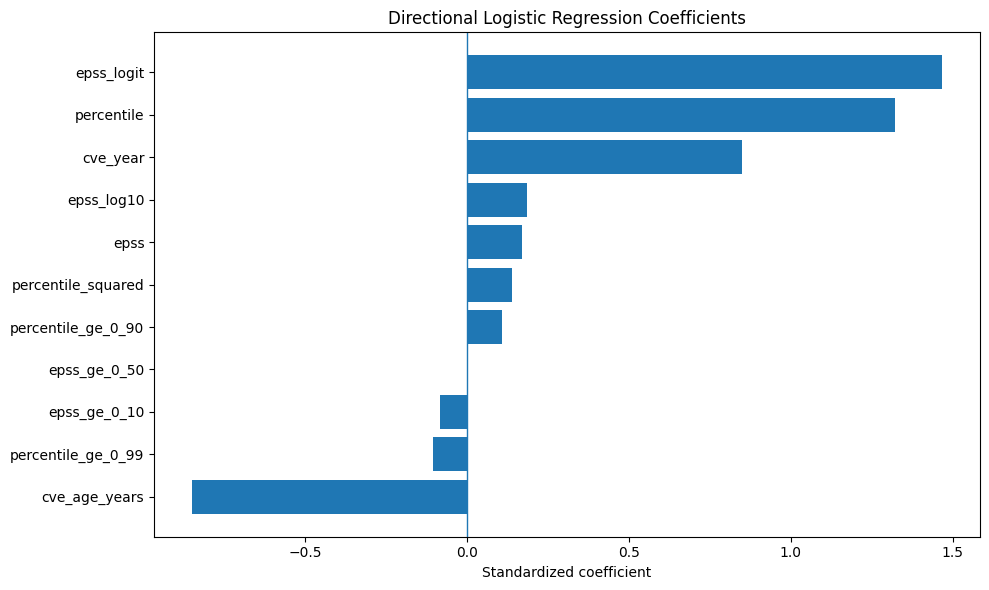

In [2]:
coefficients = xai["coefficients"]

display(
    coefficients[
        [
            "feature",
            "standardized_coefficient",
            "direction",
            "odds_ratio_per_standard_deviation",
        ]
    ]
)

ordered = coefficients.sort_values(
    "standardized_coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    ordered["feature"],
    ordered["standardized_coefficient"],
)

plt.axvline(
    0.0,
    linewidth=1,
)

plt.title(
    "Directional Logistic Regression Coefficients"
)

plt.xlabel(
    "Standardized coefficient"
)

plt.tight_layout()
plt.show()

## 2. Representative decision outcomes

The model evidence includes examples of:

- True positive
- False positive
- False negative
- True negative

The two failure categories are retained deliberately
because they expose model weaknesses.

In [3]:
examples = xai["examples"]

display(examples)

counts = report[
    "weakness_analysis"
]["outcome_counts"]

print(
    "True positives:",
    counts["TRUE_POSITIVE"],
)

print(
    "False positives:",
    counts["FALSE_POSITIVE"],
)

print(
    "False negatives:",
    counts["FALSE_NEGATIVE"],
)

print(
    "True negatives:",
    counts["TRUE_NEGATIVE"],
)

,cve,outcome_type,actual_is_kev,prediction,predicted_probability,reconstructed_probability,reconstruction_error,decision_logit,epss,percentile,cve_year,cve_age_years
0,CVE-2024-21887,TRUE_POSITIVE,1,1,0.999997,0.999997,1.110223e-16,12.782665,0.99999,0.99999,2024,2
1,CVE-2024-29826,FALSE_POSITIVE,0,1,0.999927,0.999927,0.000000e+00,9.525649,0.99877,0.99964,2024,2
2,CVE-2023-46748,FALSE_NEGATIVE,1,0,0.844005,0.844005,0.000000e+00,1.688334,0.04468,0.90389,2023,3
3,CVE-1999-1101,TRUE_NEGATIVE,0,0,0.000014,0.000014,0.000000e+00,-11.143670,0.00246,0.15777,1999,27


True positives: 250
False positives: 1844
False negatives: 79
True negatives: 67726


## 3. Exact local additive explanations

Each standardized feature contributes additively to the
Logistic Regression decision logit.

The intercept plus all feature contributions reconstructs
the predicted probability.


TRUE_POSITIVE


,cve,feature,raw_value,standardized_value,logit_contribution,direction
33,CVE-2024-21887,epss_logit,11.512915,7.293991,10.706529,TOWARD_KEV
34,CVE-2024-21887,percentile,0.999990,1.534247,2.025523,TOWARD_KEV
35,CVE-2024-21887,epss,0.999990,5.027805,0.858393,TOWARD_KEV
36,CVE-2024-21887,cve_year,2024.000000,0.744578,0.632613,TOWARD_KEV
37,CVE-2024-21887,cve_age_years,2.000000,-0.744578,0.632613,TOWARD_KEV
38,CVE-2024-21887,epss_log10,-0.000004,2.838028,0.530361,TOWARD_KEV
39,CVE-2024-21887,percentile_ge_0_99,1.000000,4.654463,-0.490525,AWAY_FROM_KEV
40,CVE-2024-21887,percentile_squared,0.999980,1.900210,0.266793,TOWARD_KEV


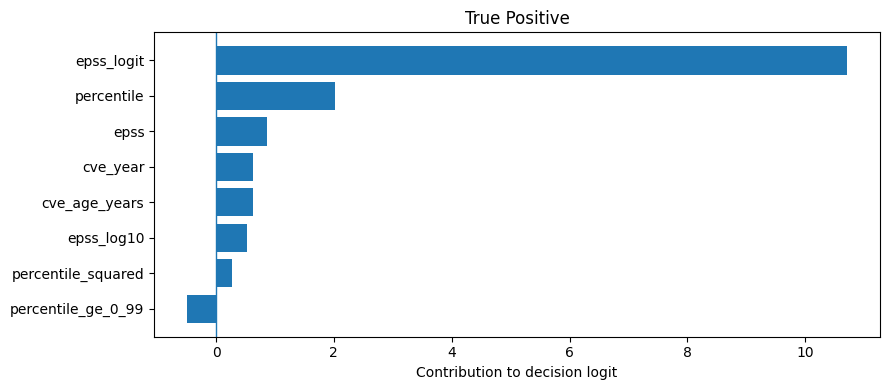


FALSE_POSITIVE


,cve,feature,raw_value,standardized_value,logit_contribution,direction
11,CVE-2024-29826,epss_logit,6.699510,5.077202,7.452602,TOWARD_KEV
12,CVE-2024-29826,percentile,0.999640,1.533091,2.023997,TOWARD_KEV
13,CVE-2024-29826,epss,0.998770,5.021249,0.857273,TOWARD_KEV
14,CVE-2024-29826,cve_year,2024.000000,0.744578,0.632613,TOWARD_KEV
15,CVE-2024-29826,cve_age_years,2.000000,-0.744578,0.632613,TOWARD_KEV
16,CVE-2024-29826,epss_log10,-0.000535,2.837259,0.530217,TOWARD_KEV
17,CVE-2024-29826,percentile_ge_0_99,1.000000,4.654463,-0.490525,AWAY_FROM_KEV
18,CVE-2024-29826,percentile_squared,0.999280,1.898071,0.266493,TOWARD_KEV


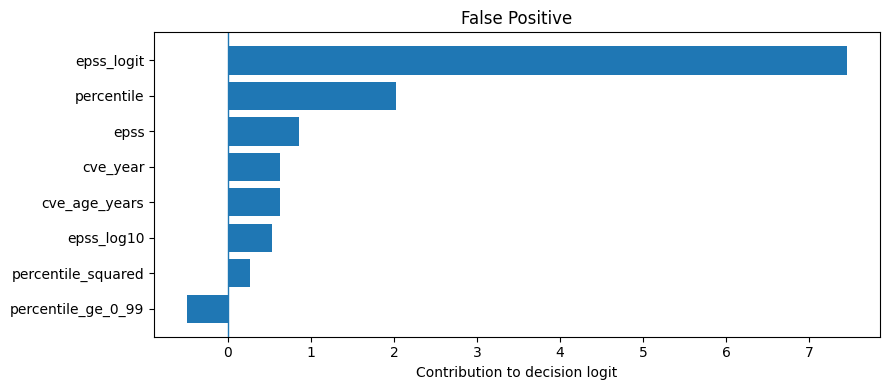


FALSE_NEGATIVE


,cve,feature,raw_value,standardized_value,logit_contribution,direction
0,CVE-2023-46748,percentile,0.903890,1.216966,1.606646,TOWARD_KEV
1,CVE-2023-46748,epss_logit,-3.062520,0.581349,0.853336,TOWARD_KEV
2,CVE-2023-46748,cve_year,2023.000000,0.583387,0.495661,TOWARD_KEV
3,CVE-2023-46748,cve_age_years,3.000000,-0.583387,0.495661,TOWARD_KEV
4,CVE-2023-46748,percentile_ge_0_90,1.000000,2.335790,0.250653,TOWARD_KEV
5,CVE-2023-46748,percentile_squared,0.817017,1.340995,0.188278,TOWARD_KEV
6,CVE-2023-46748,epss_log10,-1.349887,0.878074,0.164091,TOWARD_KEV
7,CVE-2023-46748,epss_ge_0_10,0.000000,-0.335663,0.027909,TOWARD_KEV


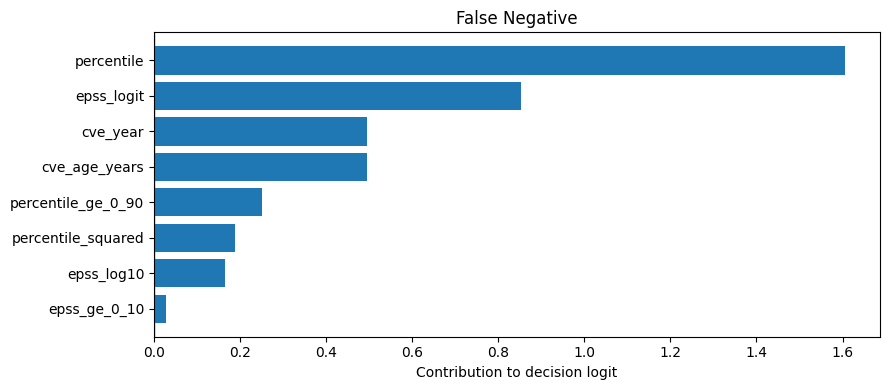


TRUE_NEGATIVE


,cve,feature,raw_value,standardized_value,logit_contribution,direction
22,CVE-1999-1101,cve_year,1999.000000,-3.285188,-2.791183,AWAY_FROM_KEV
23,CVE-1999-1101,cve_age_years,27.000000,3.285188,-2.791183,AWAY_FROM_KEV
24,CVE-1999-1101,percentile,0.157770,-1.246401,-1.645508,AWAY_FROM_KEV
25,CVE-1999-1101,epss_logit,-6.005131,-0.773856,-1.135909,AWAY_FROM_KEV
26,CVE-1999-1101,epss_log10,-2.609065,-0.950184,-0.177567,AWAY_FROM_KEV
27,CVE-1999-1101,percentile_squared,0.024891,-1.080090,-0.151647,AWAY_FROM_KEV
28,CVE-1999-1101,epss,0.002460,-0.333418,-0.056924,AWAY_FROM_KEV
29,CVE-1999-1101,percentile_ge_0_90,0.000000,-0.428121,-0.045941,AWAY_FROM_KEV


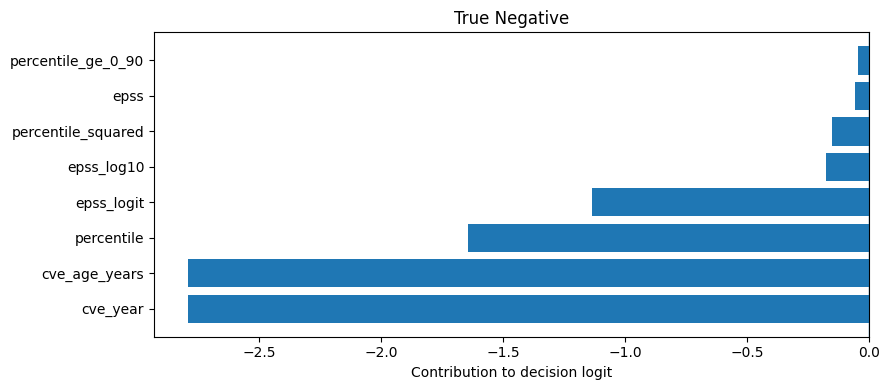

In [4]:
contributions = xai["contributions"]

for outcome in [
    "TRUE_POSITIVE",
    "FALSE_POSITIVE",
    "FALSE_NEGATIVE",
    "TRUE_NEGATIVE",
]:
    print()
    print(outcome)

    selected = (
        contributions[
            contributions["outcome_type"]
            == outcome
        ]
        .sort_values(
            "absolute_contribution",
            ascending=False,
        )
        .head(8)
    )

    display(
        selected[
            [
                "cve",
                "feature",
                "raw_value",
                "standardized_value",
                "logit_contribution",
                "direction",
            ]
        ]
    )

    chart = selected.sort_values(
        "logit_contribution"
    )

    plt.figure(figsize=(9, 4))

    plt.barh(
        chart["feature"],
        chart["logit_contribution"],
    )

    plt.axvline(
        0.0,
        linewidth=1,
    )

    plt.title(
        outcome.replace(
            "_",
            " ",
        ).title()
    )

    plt.xlabel(
        "Contribution to decision logit"
    )

    plt.tight_layout()
    plt.show()

## 4. Probability reconstruction assurance

The local explanation must mathematically reconstruct
the model probability. This prevents decorative or
approximate explanations from being presented as exact.

In [5]:
error = report[
    "local_explanation"
][
    "maximum_probability_reconstruction_error"
]

print(
    "Maximum reconstruction error:",
    error,
)

assert error < 1e-9

print(
    "Local explanation fidelity: PASS"
)

Maximum reconstruction error: 1.1102230246251565e-16
Local explanation fidelity: PASS


## 5. Automated weakness slices

Errors are analyzed by:

- EPSS band
- CVE age band

This shows where review burden and missed detections
concentrate.

In [6]:
slices = xai["slices"]

display(slices)

for dimension in [
    "epss_band",
    "age_band",
]:
    print()
    print(dimension)

    selected = slices[
        slices["slice_dimension"]
        == dimension
    ]

    display(selected)

,slice_dimension,slice_value,rows,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
0,epss_band,0_TO_1_PERCENT,41056,0,0,10,41046,NaN,0.000000,0.000000,1.000000
1,epss_band,1_TO_10_PERCENT,25358,16,409,51,24882,0.037647,0.238806,0.016172,0.761194
2,epss_band,10_TO_50_PERCENT,2612,63,903,17,1629,0.065217,0.787500,0.356635,0.212500
3,epss_band,50_TO_100_PERCENT,873,171,532,1,169,0.243243,0.994186,0.758916,0.005814
4,age_band,AGE_0_TO_2,22938,73,481,27,22357,0.131769,0.730000,0.021061,0.270000
5,age_band,AGE_3_TO_5,15813,80,648,15,15070,0.109890,0.842105,0.041227,0.157895
6,age_band,AGE_6_TO_10,15251,76,595,21,14559,0.113264,0.783505,0.039264,0.216495
7,age_band,AGE_11_TO_20,12726,21,120,14,12571,0.148936,0.600000,0.009456,0.400000
8,age_band,AGE_OVER_20,3171,0,0,2,3169,NaN,0.000000,0.000000,1.000000



epss_band


,slice_dimension,slice_value,rows,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
0,epss_band,0_TO_1_PERCENT,41056,0,0,10,41046,NaN,0.000000,0.000000,1.000000
1,epss_band,1_TO_10_PERCENT,25358,16,409,51,24882,0.037647,0.238806,0.016172,0.761194
2,epss_band,10_TO_50_PERCENT,2612,63,903,17,1629,0.065217,0.787500,0.356635,0.212500
3,epss_band,50_TO_100_PERCENT,873,171,532,1,169,0.243243,0.994186,0.758916,0.005814



age_band


,slice_dimension,slice_value,rows,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
4,age_band,AGE_0_TO_2,22938,73,481,27,22357,0.131769,0.730000,0.021061,0.270000
5,age_band,AGE_3_TO_5,15813,80,648,15,15070,0.109890,0.842105,0.041227,0.157895
6,age_band,AGE_6_TO_10,15251,76,595,21,14559,0.113264,0.783505,0.039264,0.216495
7,age_band,AGE_11_TO_20,12726,21,120,14,12571,0.148936,0.600000,0.009456,0.400000
8,age_band,AGE_OVER_20,3171,0,0,2,3169,NaN,0.000000,0.000000,1.000000


## 6. Automated XAI and governance checks

In [7]:
checks = pd.DataFrame(
    [
        {
            "Check": key,
            "Passed": value,
        }
        for key, value in report[
            "quality_gate"
        ]["checks"].items()
    ]
)

display(checks)

assert checks["Passed"].all()

print(
    "Automated XAI checks: PASS"
)

,Check,Passed
0,all_four_outcomes_present,True
1,false_negatives_detected,True
2,false_positives_detected,True
3,label_excluded_from_features,True
4,model_advisory_only,True
5,probability_reconstruction_error_below_1e_9,True
6,production_blocked,True
7,ssvc_authority_preserved,True


Automated XAI checks: PASS


## 7. Week 3 conclusion

AegisSec-FedOps now demonstrates:

- Multi-model comparison
- Class-imbalance-aware evaluation
- Global permutation importance
- Directional coefficients
- Odds ratios
- Local TP, FP, FN and TN explanations
- Exact probability reconstruction
- EPSS and CVE-age weakness slices
- Automated XAI assurance tests
- More than 80% focused XAI coverage
- At least 80% full-source coverage
- SSVC authority preservation
- Advisory-only machine learning
- Production blocking

The false-positive burden shows why the model requires
human review. The false negatives show why it cannot
replace CISA KEV evidence or SSVC.